In [43]:
# %% Imports
import pandas as pd

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from zoneinfo import ZoneInfo

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['figure.dpi'] = 100

DATA_PATH = '../data/wraggled_cities.csv'

In [44]:
df = pd.read_csv(DATA_PATH, low_memory=False)
df[['started_at', 'finished_at']] = df[['started_at', 'finished_at']].apply(pd.to_datetime, utc=True)

kyiv_tz = ZoneInfo("Europe/Kyiv")
df['started_at'] = df['started_at'].dt.tz_convert(kyiv_tz)
df['finished_at'] = df['finished_at'].dt.tz_convert(kyiv_tz)
df.head()

,city,started_at,finished_at,duration,duration_min,_src
0,Dnipro,2022-03-15 21:23:40+02:00,2022-03-15 21:41:59+02:00,0 days 00:18:19,18.316667,oblast
1,Dnipro,2022-03-16 02:50:45+02:00,2022-03-16 06:17:20+02:00,0 days 03:26:35,206.583333,oblast
2,Dnipro,2022-03-16 13:37:15+02:00,2022-03-16 13:56:27+02:00,0 days 00:19:12,19.200000,raion
3,Dnipro,2022-03-16 22:36:05+02:00,2022-03-16 23:15:40+02:00,0 days 00:39:35,39.583333,oblast
4,Dnipro,2022-03-17 12:45:28+02:00,2022-03-17 13:50:14+02:00,0 days 01:04:46,64.766667,oblast


In [45]:
df.head()

,city,started_at,finished_at,duration,duration_min,_src
0,Dnipro,2022-03-15 21:23:40+02:00,2022-03-15 21:41:59+02:00,0 days 00:18:19,18.316667,oblast
1,Dnipro,2022-03-16 02:50:45+02:00,2022-03-16 06:17:20+02:00,0 days 03:26:35,206.583333,oblast
2,Dnipro,2022-03-16 13:37:15+02:00,2022-03-16 13:56:27+02:00,0 days 00:19:12,19.200000,raion
3,Dnipro,2022-03-16 22:36:05+02:00,2022-03-16 23:15:40+02:00,0 days 00:39:35,39.583333,oblast
4,Dnipro,2022-03-17 12:45:28+02:00,2022-03-17 13:50:14+02:00,0 days 01:04:46,64.766667,oblast


In [46]:
df.sort_values('duration_min', ascending=False).reset_index(drop=True)

,city,started_at,finished_at,duration,duration_min,_src
0,Kharkiv,2024-05-12 11:37:29+03:00,2026-01-06 11:53:57+02:00,604 days 01:16:28,869836.466667,raion
1,Zaporizhzhia,2026-02-05 18:23:24+02:00,2026-02-07 11:58:23+02:00,1 days 17:34:59,2494.983333,raion
2,Kharkiv,2026-02-28 06:08:57+02:00,2026-03-01 18:47:17+02:00,1 days 12:38:20,2198.333333,raion
3,Zaporizhzhia,2026-06-09 03:12:51+03:00,2026-06-10 13:03:15+03:00,1 days 09:50:24,2030.400000,raion
4,Zaporizhzhia,2026-01-29 07:32:15+02:00,2026-01-30 17:13:06+02:00,1 days 09:40:51,2020.850000,raion
...,...,...,...,...,...,...
36877,Dnipro,2025-03-05 15:28:44+02:00,2025-03-05 15:28:47+02:00,0 days 00:00:03,0.050000,oblast
36878,Dnipro,2025-10-01 03:26:43+03:00,2025-10-01 03:26:46+03:00,0 days 00:00:03,0.050000,oblast
36879,Kharkiv,2023-05-23 09:20:40+03:00,2023-05-23 09:20:43+03:00,0 days 00:00:03,0.050000,oblast
36880,Kharkiv,2022-11-17 12:51:31+02:00,2022-11-17 12:51:33+02:00,0 days 00:00:02,0.033333,oblast


Earlier, I stated that data is clear enoguh, but 604 days air alert in Kharkiv is a strange entity which seems like error requires analysis.

In [47]:
kharkiv_df = df[df['city'] == 'Kharkiv'].sort_values('started_at')
kharkiv_df[kharkiv_df['duration_min'] > 60 * 24]  # alerts over 24 hours

,city,started_at,finished_at,duration,duration_min,_src
10936,Kharkiv,2024-05-12 11:37:29+03:00,2026-01-06 11:53:57+02:00,604 days 01:16:28,869836.466667,raion
14034,Kharkiv,2026-02-28 06:08:57+02:00,2026-03-01 18:47:17+02:00,1 days 12:38:20,2198.333333,raion


In [68]:
kharkiv_df[
    (kharkiv_df['started_at'] >= '2024-07-01') &
    (kharkiv_df['finished_at'] <= '2025-01-01')
    ].reset_index(drop=True)

,city,started_at,finished_at,duration,duration_min,_src


We see that there are no air alerts in Kharkiv between '2024-07-01' and '2025-01-01'. Anyway, artifact with 604 is unsuitable for analysis. Thus, we have following options:
- Exclude Kharkiv from analysis, which leads to lose of analytical potential
- Use Kharkiv without this period, explicitly mentioning that

In my analysis I will consider 2nd option.

In [51]:
# %% Bucket decomposition

BUCKETS = [
    ('night', 0, 6 * 60),  # 00:00–06:00  (continuation of prev night)
    ('morning', 6 * 60, 12 * 60),
    ('afternoon', 12 * 60, 18 * 60),
    ('evening', 18 * 60, 23 * 60),
    ('night_end', 23 * 60, 24 * 60),  # 23:00–24:00 → belongs to same calendar day as 23:00
]


def minutes_since_midnight(dt):
    return dt.hour * 60 + dt.minute + dt.second / 60


def carve_interval(start_utc, end_utc):
    if start_utc >= end_utc:
        return

    day = start_utc.date()
    day_origin = pd.Timestamp(day, tz=start_utc.tzinfo)
    s_min = minutes_since_midnight(start_utc)

    for bucket, b_start, b_end in BUCKETS:
        if s_min >= b_end:
            continue

        seg_start = start_utc
        seg_end = min(end_utc, day_origin + pd.Timedelta(minutes=b_end))

        if seg_start >= seg_end:
            continue

        duration = (seg_end - seg_start).total_seconds() / 60
        out_bucket = 'night' if bucket == 'night_end' else bucket

        # 00:00–06:00 segment belongs to the previous calendar day
        out_day = (day - pd.Timedelta(days=1)) if bucket == 'night' else day

        yield (out_day, out_bucket, duration)

        if seg_end < end_utc:
            yield from carve_interval(seg_end, end_utc)
        return


# %% Apply to df
records = []
for row in df[['city', 'started_at', 'finished_at']].itertuples(index=False):
    for date, bucket, mins in carve_interval(row.started_at, row.finished_at):
        records.append({'city': row.city, 'date': date, 'bucket': bucket, 'minutes': mins})

segments = pd.DataFrame(records)

# %% Pivot and fill missing city-date combinations with zero
buckets_df = (
    segments
    .groupby(['city', 'date', 'bucket'])['minutes']
    .sum()
    .unstack('bucket', fill_value=0)
    .reindex(columns=['night', 'morning', 'afternoon', 'evening'], fill_value=0)
    .rename(columns=lambda c: f'{c}_min')
    .reset_index()
)

# Fill every city × date combination with zeros
all_dates = pd.date_range(buckets_df['date'].min(), buckets_df['date'].max(), freq='D').date
all_cities = buckets_df['city'].unique()
full_index = pd.MultiIndex.from_product([all_cities, all_dates], names=['city', 'date'])

buckets_df = (
    buckets_df
    .set_index(['city', 'date'])
    .reindex(full_index, fill_value=0)
    .reset_index()
)

buckets_df['total_min'] = buckets_df[['night_min', 'morning_min', 'afternoon_min', 'evening_min']].sum(axis=1)

print(f'Shape: {buckets_df.shape}')
buckets_df.head(10)

Shape: (10913, 7)


bucket,city,date,night_min,morning_min,afternoon_min,evening_min,total_min
0,Dnipro,2022-03-15,189.250000,0.000000,0.000000,18.316667,207.566667
1,Dnipro,2022-03-16,15.666667,17.333333,19.200000,23.916667,76.116667
2,Dnipro,2022-03-17,6.066667,0.000000,64.766667,0.000000,70.833333
3,Dnipro,2022-03-18,0.000000,138.516667,50.466667,0.000000,188.983333
4,Dnipro,2022-03-19,33.583333,0.000000,52.000000,58.533333,144.116667
5,Dnipro,2022-03-20,0.000000,26.733333,0.000000,26.750000,53.483333
6,Dnipro,2022-03-21,0.000000,0.000000,120.133333,58.000000,178.133333
7,Dnipro,2022-03-22,12.333333,92.466667,146.133333,144.750000,395.683333
8,Dnipro,2022-03-23,22.300000,31.416667,0.000000,152.000000,205.716667
9,Dnipro,2022-03-24,56.616667,89.500000,7.166667,60.800000,214.083333


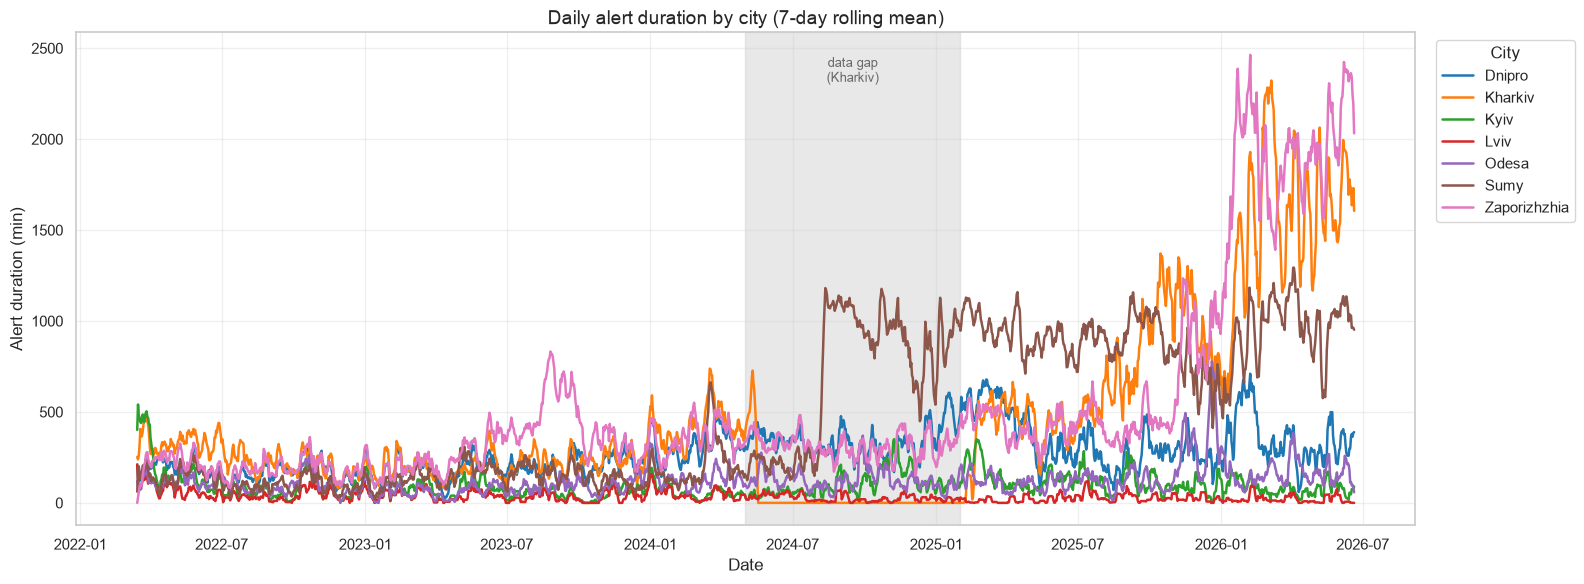

In [70]:
# %% Total alert minutes per day – all cities with 7-day rolling mean
GAP_START = pd.Timestamp('2024-05-01')
GAP_END = pd.Timestamp('2025-02-01')

fig, ax = plt.subplots(figsize=(16, 6))

palette = sns.color_palette('tab10', n_colors=buckets_df['city'].nunique())

for color, (city, group) in zip(palette, buckets_df.groupby('city')):
    group = group.sort_values('date')
    dates = pd.to_datetime(group['date'])
    roll = group['total_min'].rolling(7, min_periods=1).mean()

    ax.plot(dates, roll, linewidth=1.8, color=color, label=city)

# Shaded gap rectangle
ax.axvspan(GAP_START, GAP_END, color='lightgrey', alpha=0.5, zorder=0)
ax.text(
    GAP_START + (GAP_END - GAP_START) / 2, ax.get_ylim()[1] * 0.95,
    'data gap\n(Kharkiv)',
    ha='center', va='top', fontsize=9, color='dimgrey'
)

ax.set_title('Daily alert duration by city (7-day rolling mean)', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Alert duration (min)')
ax.legend(title='City', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Note that for the Kharkiv we see flat period, which is expected (the reason is described above).

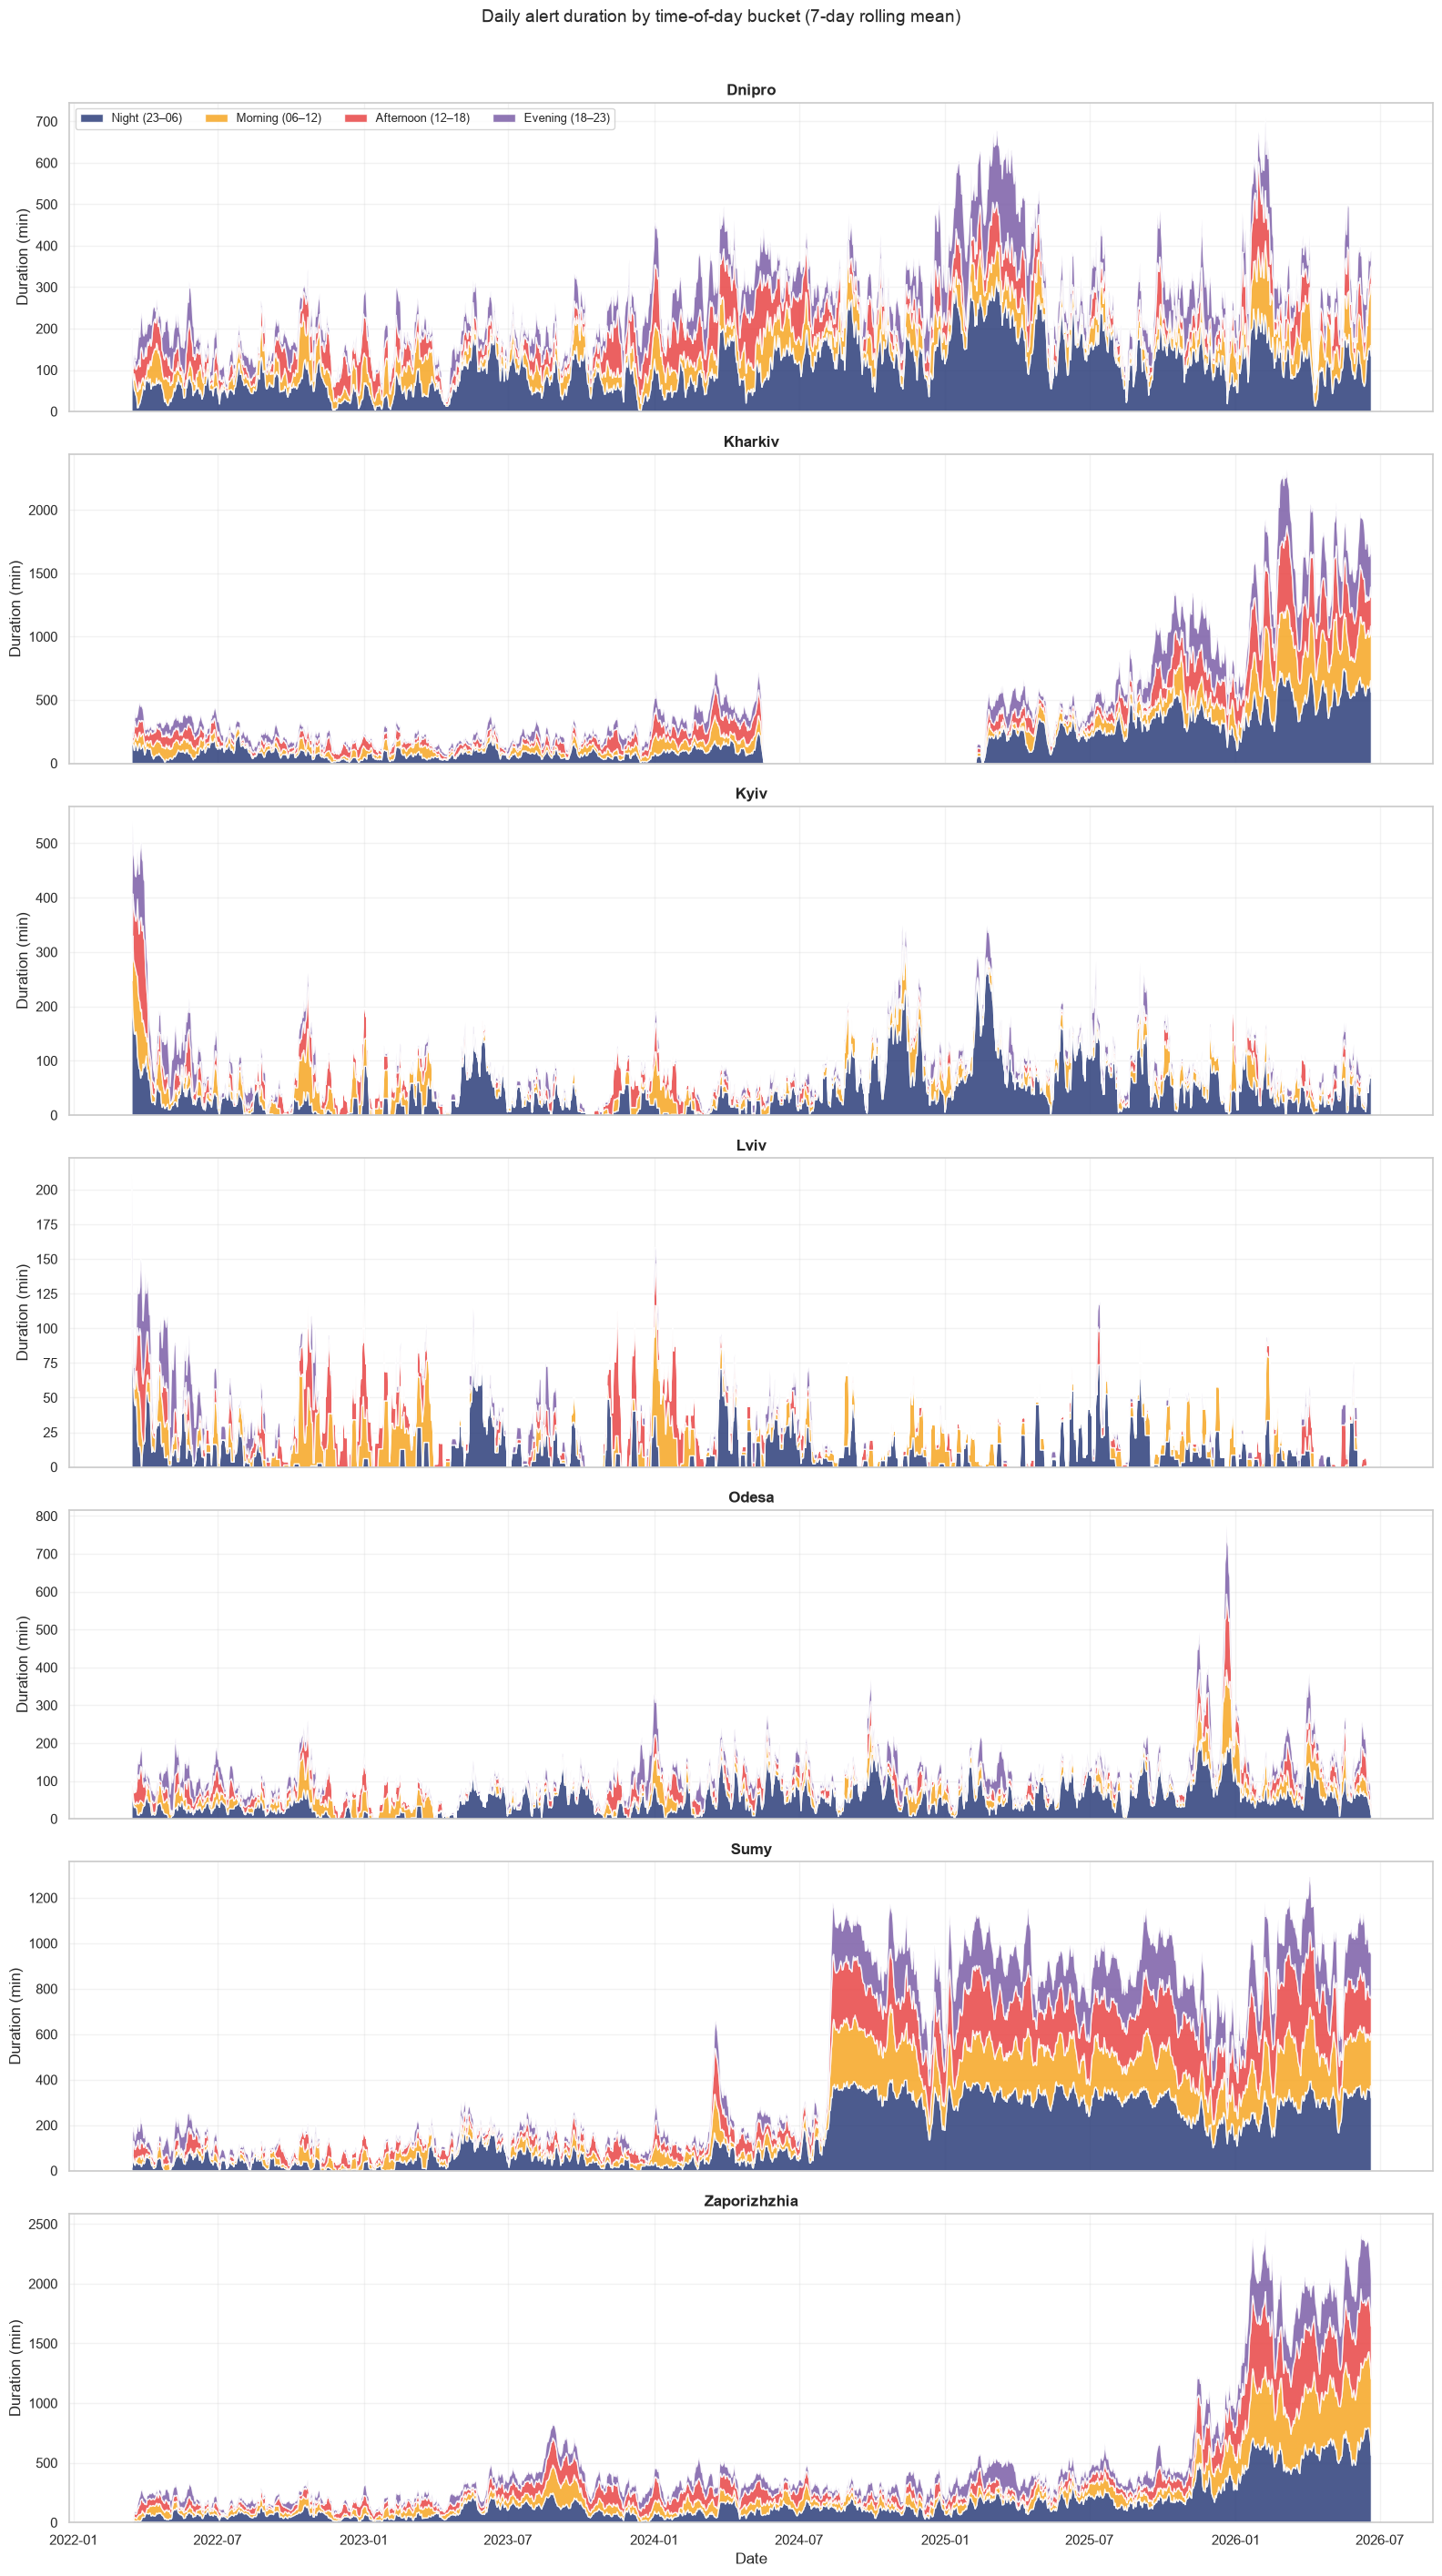

In [71]:
# %% Stacked area chart of bucket minutes per city (7-day rolling mean)

BUCKET_COLS = ['night_min', 'morning_min', 'afternoon_min', 'evening_min']
BUCKET_COLORS = ['#2c3e7a', '#f6a623', '#e84545', '#7b5ea7']
BUCKET_LABELS = ['Night (23–06)', 'Morning (06–12)', 'Afternoon (12–18)', 'Evening (18–23)']

cities = buckets_df['city'].unique()
n = len(cities)

fig, axes = plt.subplots(n, 1, figsize=(16, 4 * n), sharex=True)

for ax, city in zip(axes, sorted(cities)):
    group = (
        buckets_df[buckets_df['city'] == city]
        .sort_values('date')
    )
    dates = pd.to_datetime(group['date'])
    smoothed = group[BUCKET_COLS].rolling(7, min_periods=1).mean().values

    ax.stackplot(dates, smoothed.T, labels=BUCKET_LABELS, colors=BUCKET_COLORS, alpha=0.85)
    ax.set_title(city, fontsize=12, fontweight='bold')
    ax.set_ylabel('Duration (min)')
    ax.grid(True, alpha=0.25)

axes[0].legend(loc='upper left', fontsize=9, ncol=4)
axes[-1].set_xlabel('Date')
fig.suptitle('Daily alert duration by time-of-day bucket (7-day rolling mean)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# City Analytical Summaries

**Kyiv** — Unlike every other city in the dataset, Kyiv was most heavily affected in the opening weeks of the war and has since maintained a moderate, relatively flat alert burden, with a distinctively high and growing night share that reflects deliberate long-range strike timing rather than frontline proximity.

**Kharkiv** — As Ukraine's second-largest city and closest major urban center to the Russian border, Kharkiv shows the highest sustained alert intensity among all cities in the valid data periods, with a significant data gap from May 2024 to February 2025 that likely understates its true cumulative exposure.

**Dnipro** — The most consistently active city across the entire war period, Dnipro never drops to near-zero and never spikes dramatically, suggesting it has been a persistent rather than episodic target throughout 2022–2026.

**Zaporizhzhia** — Shows the most explosive recent escalation in the dataset, moving from near-zero alert activity through mid-2024 to the highest daily durations of any city by 2026, reflecting its proximity to the expanding southern frontline.

**Odesa** — Follows the rear-city pattern of Kyiv with a meaningful night share rise through 2023, but also shows a dramatic December 2023 spike in total duration that stands out as a city-specific event distinct from broader nationwide patterns.

**Lviv** — The clearest baseline in the dataset, with sparse and isolated alert activity throughout the war that confirms its role as a low-threat western rear city, where spikes represent individual strike events rather than sustained campaigns.

**Sumy** — Displays the sharpest structural break of any city, transitioning almost overnight from near-zero activity through all of 2022–2024 to a sustained high-intensity alert regime from early 2025 onward, consistent with a significant escalation of cross-border threat activity in the northeast.

In [76]:
buckets_df.groupby('city')[['night_min', 'total_min']].sum().assign(
    night_share=lambda x: (x['night_min'] / x['total_min'] * 100).round(2).astype(str) + '%'
).drop(columns=['night_min', 'total_min']).sort_values('night_share', ascending=False)

bucket,night_share
city,
Kyiv,49.38%
Odesa,43.66%
Dnipro,40.44%
Kharkiv,35.7%
Lviv,33.88%
Sumy,33.8%
Zaporizhzhia,33.09%


Also note that it may depend on year, so let's verify it explicitly

In [80]:
buckets_df.assign(year=pd.to_datetime(buckets_df['date']).dt.year).groupby(['city', 'year'])[
    ['night_min', 'total_min']].sum().assign(
    night_share=lambda x: (x['night_min'] / x['total_min'] * 100).round(2).astype(str) + '%'
).drop(columns=['night_min', 'total_min']).sort_index()

bucket            night_share
city         year            
Dnipro       2022      32.63%
             2023      39.05%
             2024      38.65%
             2025      47.98%
             2026      36.38%
Kharkiv      2022      32.75%
             2023      33.35%
             2024      27.54%
             2025      43.39%
             2026      32.75%
Kyiv         2022      23.56%
             2023      49.61%
             2024      52.72%
             2025       65.9%
             2026      48.61%
Lviv         2022      17.45%
             2023      34.47%
             2024      36.35%
             2025       56.3%
             2026       36.0%
Odesa        2022      25.25%
             2023      45.54%
             2024      47.72%
             2025      51.34%
             2026      39.36%
Sumy         2022       28.0%
             2023      39.39%
             2024      34.99%
             2025      34.54%
             2026      30.35%
Zaporizhzhia 2022       32.2%
             2023      29.98%
             2024      33.15%
             2025      39.89%
             2026      30.57%

Note interesting pattern: near front-line territories have much lower night-share then Kyiv. It seems like in 2025 the number of night-share signifficantly rose up. Let's plot time-series for this one

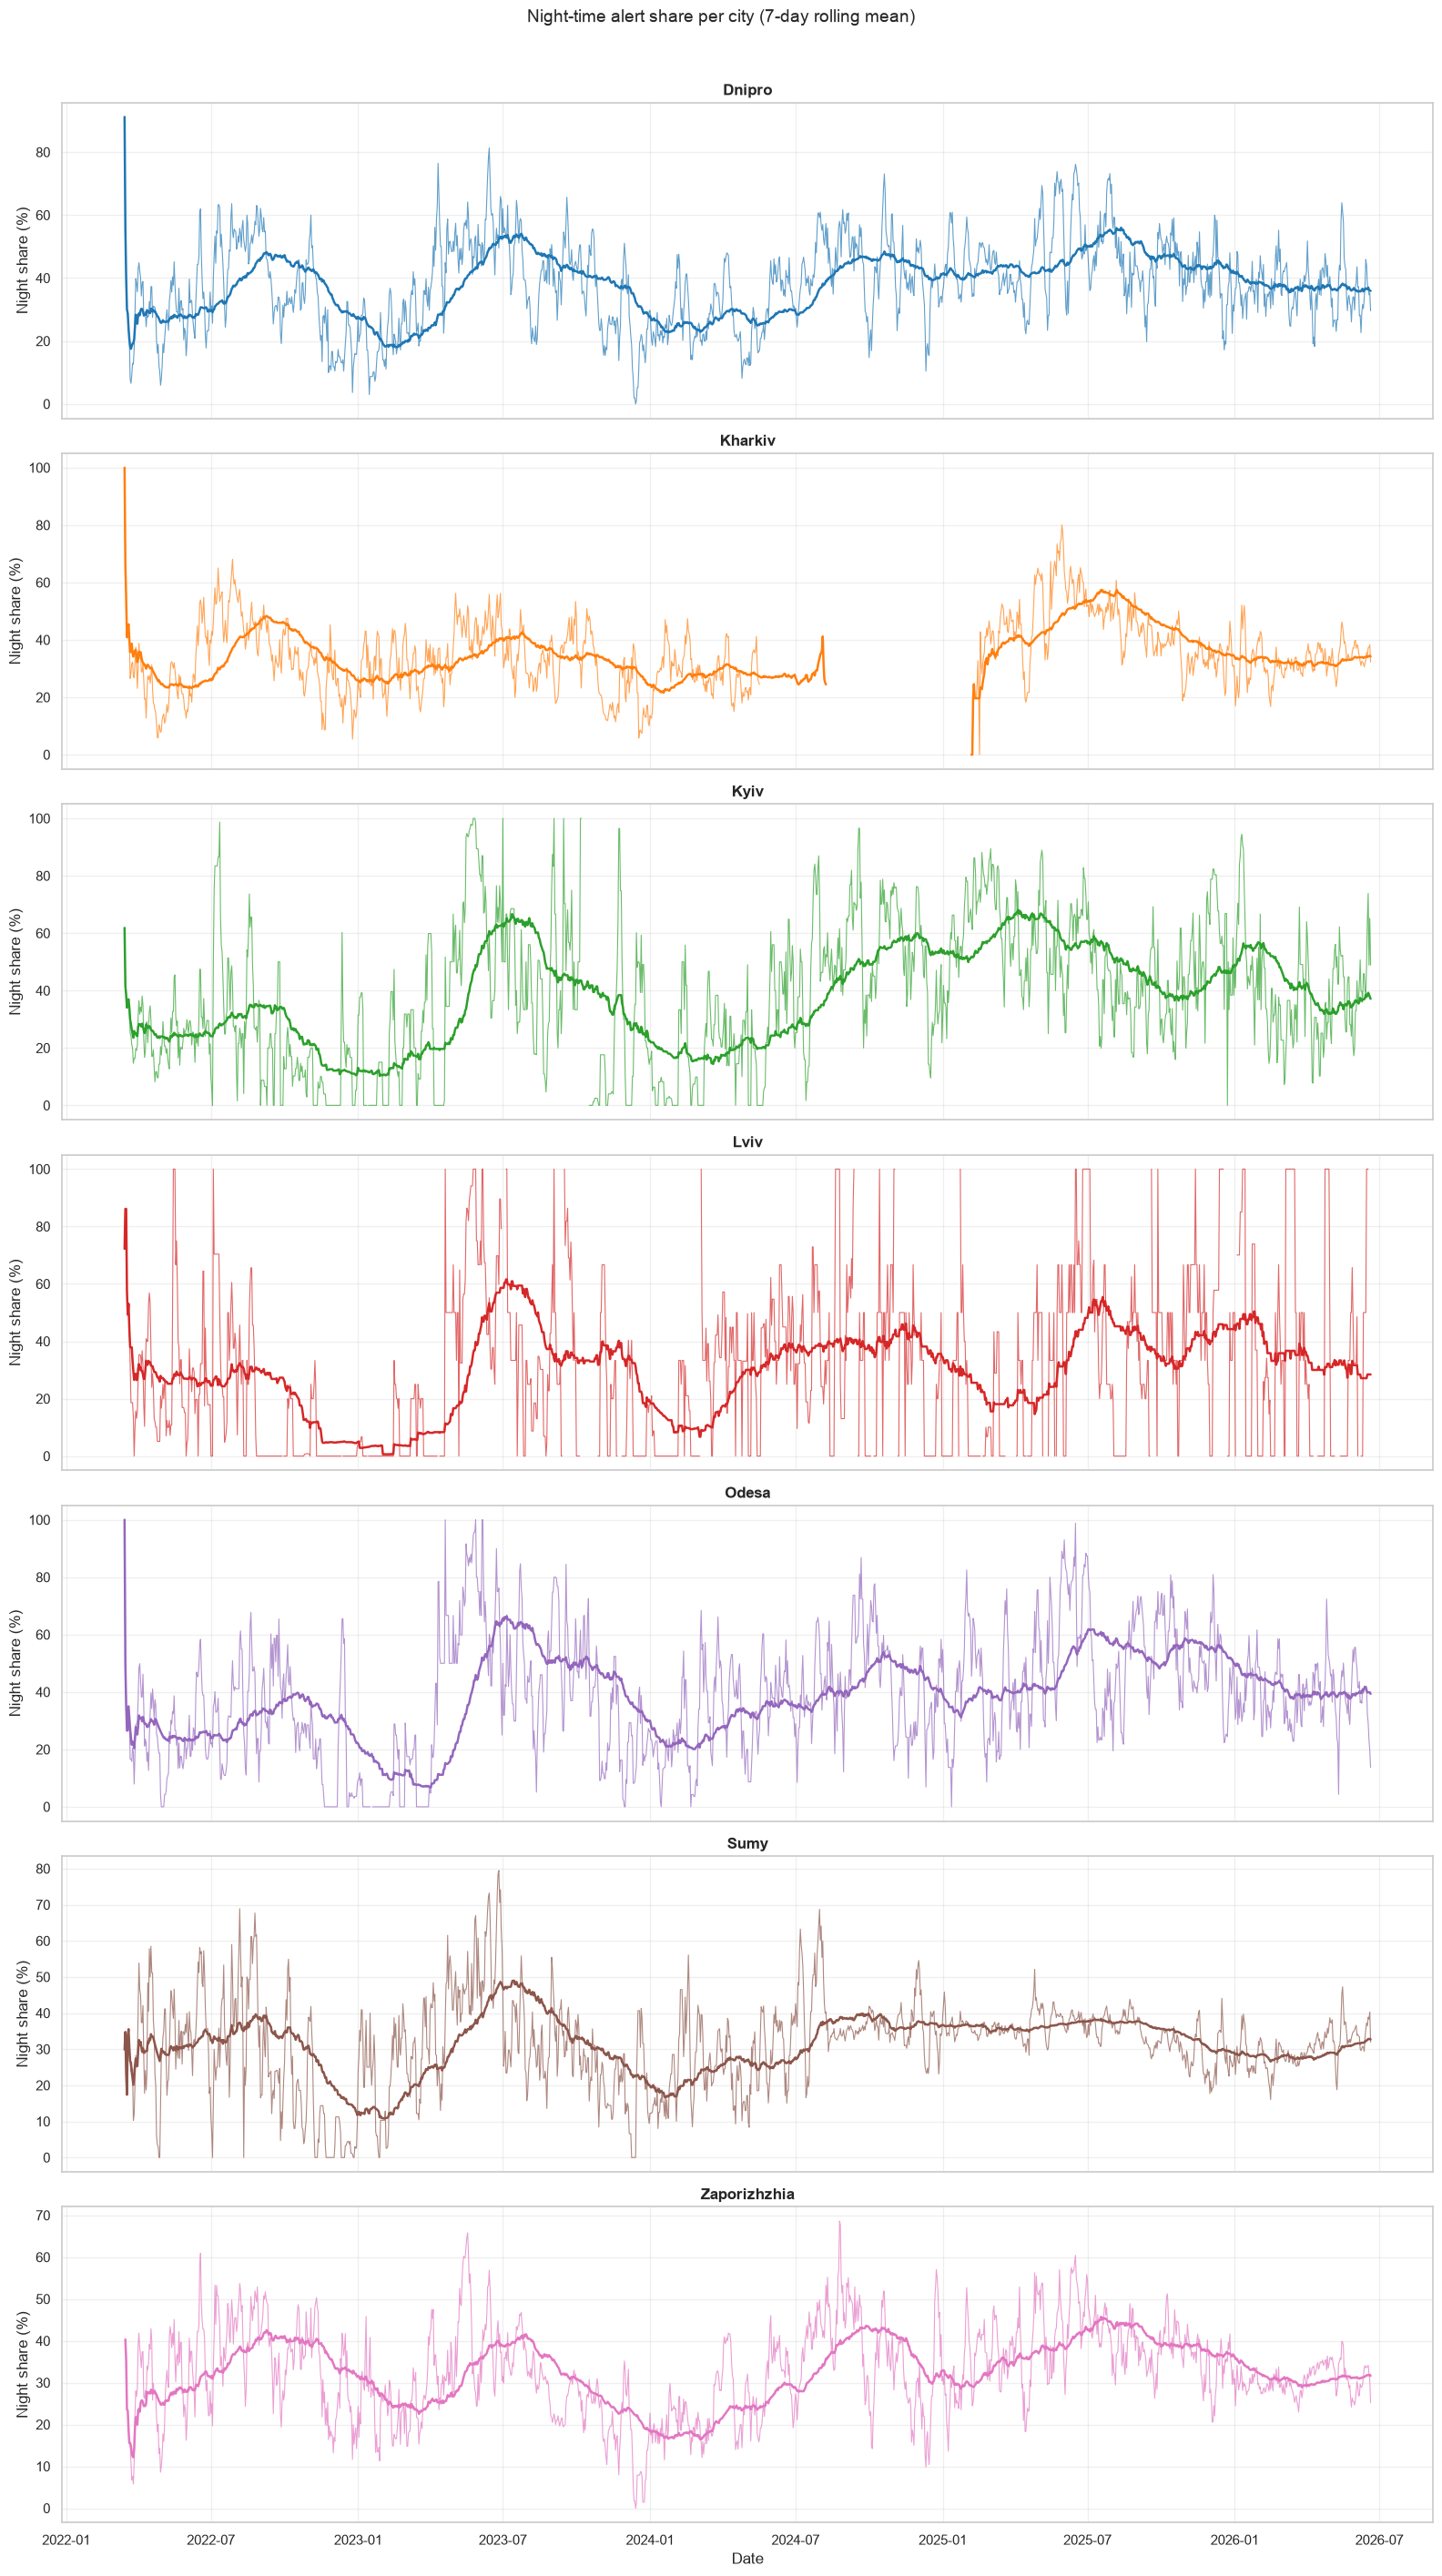

In [91]:
# %% Night-share time series per city – individual subplots (7-day rolling mean)

cities = sorted(buckets_df['city'].unique())
n = len(cities)

fig, axes = plt.subplots(n, 1, figsize=(16, 4 * n), sharex=True)

palette = sns.color_palette('tab10', n_colors=n)

for ax, color, city in zip(axes, palette, cities):
    group = buckets_df[buckets_df['city'] == city].sort_values('date')
    dates = pd.to_datetime(group['date'])

    night_share = group['night_min'] / group['total_min'].replace(0, np.nan) * 100
    month_roll = night_share.rolling(7, min_periods=1).mean()
    quarter_roll = night_share.rolling(90, min_periods=1).mean()

    ax.plot(dates, month_roll, alpha=0.7, linewidth=0.8, color=color)
    ax.plot(dates, quarter_roll, linewidth=1.8, color=color)
    ax.set_title(city, fontsize=12, fontweight='bold')
    ax.set_ylabel('Night share (%)')
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Date')
fig.suptitle('Night-time alert share per city (7-day rolling mean)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

It is clear that rear territories (including Odesa) have ~10% higher night-shares than not frontline territories generally. Also, it is clear that avg night share increased in 2025, which is what supposed.  But across all cities there is some strange spike around 2023-07. It is reasonable to investigate whether it is real effect, or just smoothing artifact. Let's first isolate year 2023.

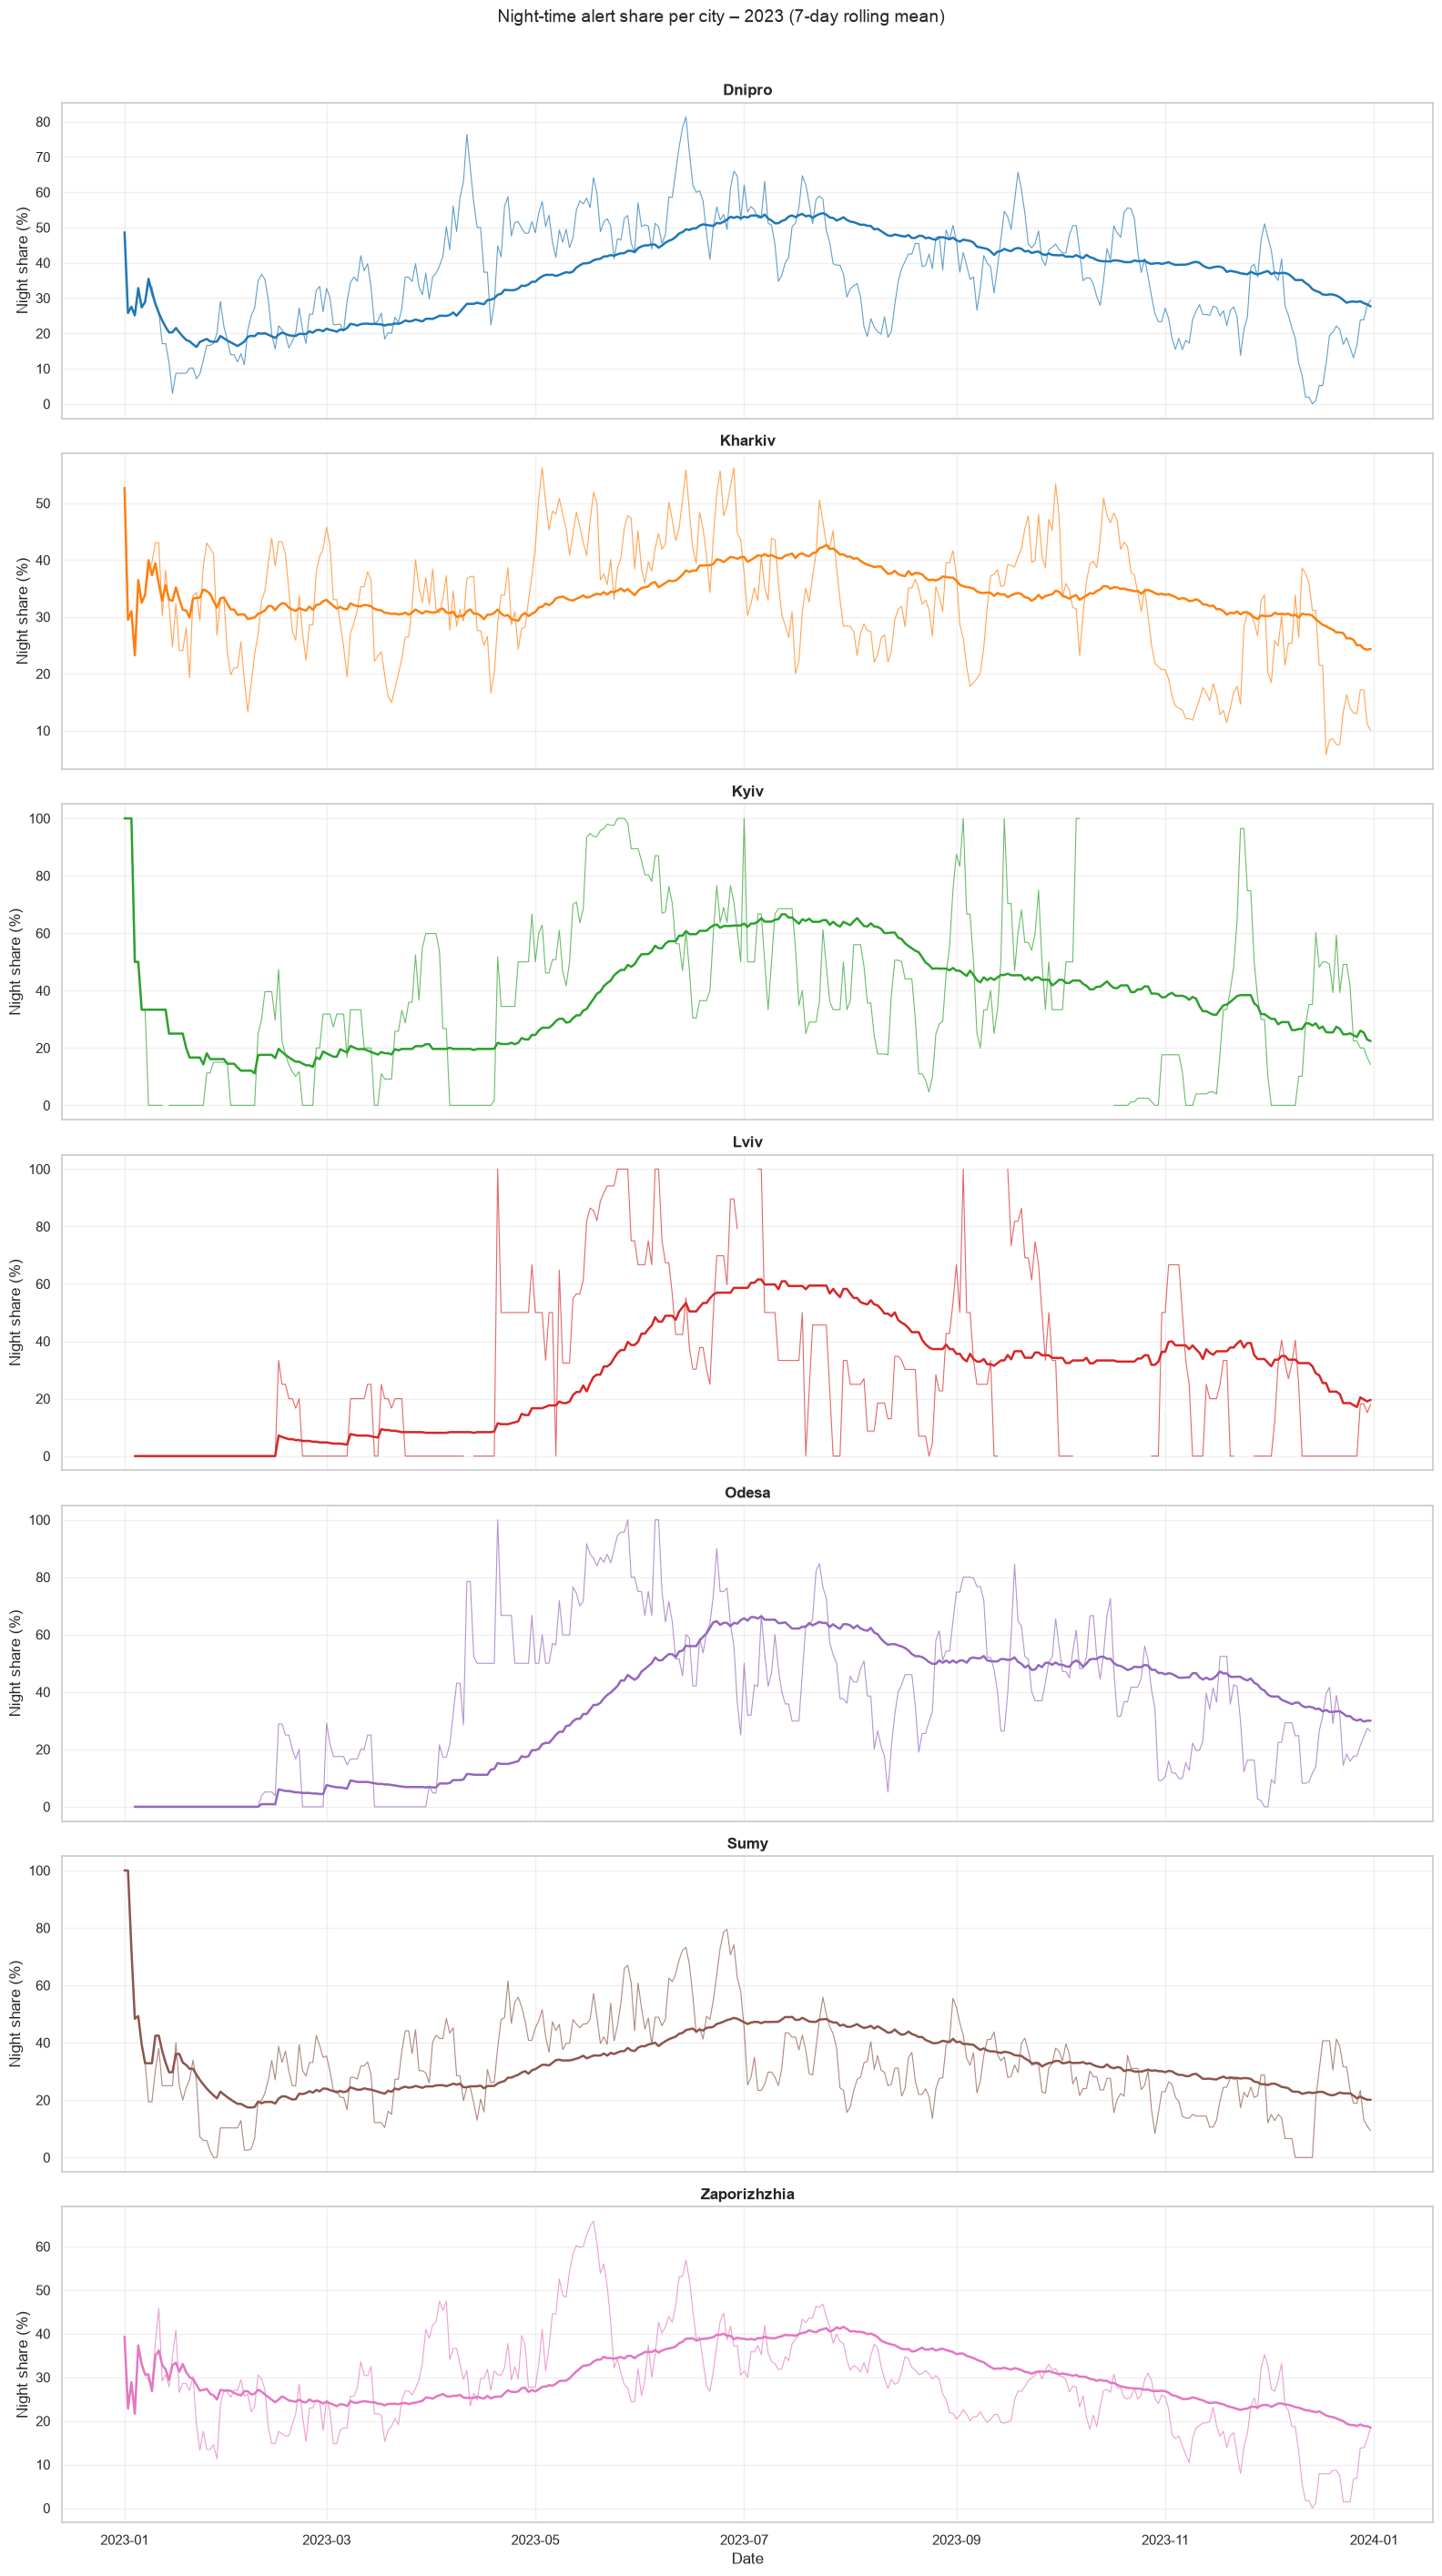

In [93]:
# %% Night-share time series per city – 2023 only (7-day rolling mean)

cities = sorted(buckets_df['city'].unique())
n      = len(cities)

fig, axes = plt.subplots(n, 1, figsize=(16, 4 * n), sharex=True)

palette = sns.color_palette('tab10', n_colors=n)

for ax, color, city in zip(axes, palette, cities):
    group = (
        buckets_df[
            (buckets_df['city'] == city) &
            (pd.to_datetime(buckets_df['date']).dt.year == 2023)
        ]
        .sort_values('date')
    )
    dates       = pd.to_datetime(group['date'])
    night_share = group['night_min'] / group['total_min'].replace(0, np.nan) * 100
    month_roll = night_share.rolling(7, min_periods=1).mean()
    quarter_roll = night_share.rolling(90, min_periods=1).mean()

    ax.plot(dates, month_roll, alpha=0.7, linewidth=0.8, color=color)
    ax.plot(dates, quarter_roll, linewidth=1.8, color=color)
    ax.set_title(city, fontsize=12, fontweight='bold')
    ax.set_ylabel('Night share (%)')
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Date')
fig.suptitle('Night-time alert share per city – 2023 (7-day rolling mean)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

Seems that the spike is the most expressed in Kyiv, Lviv, Odesa, while the least expressed in Zaporizhzhia. It probably relates to general pattern: near-frontline territories have alert more uniformly then rear.

But still, it can be smooth artifact related to generally lower number of air alerts in that period. Thus, let's build plots for absolute values of night_min and total_min

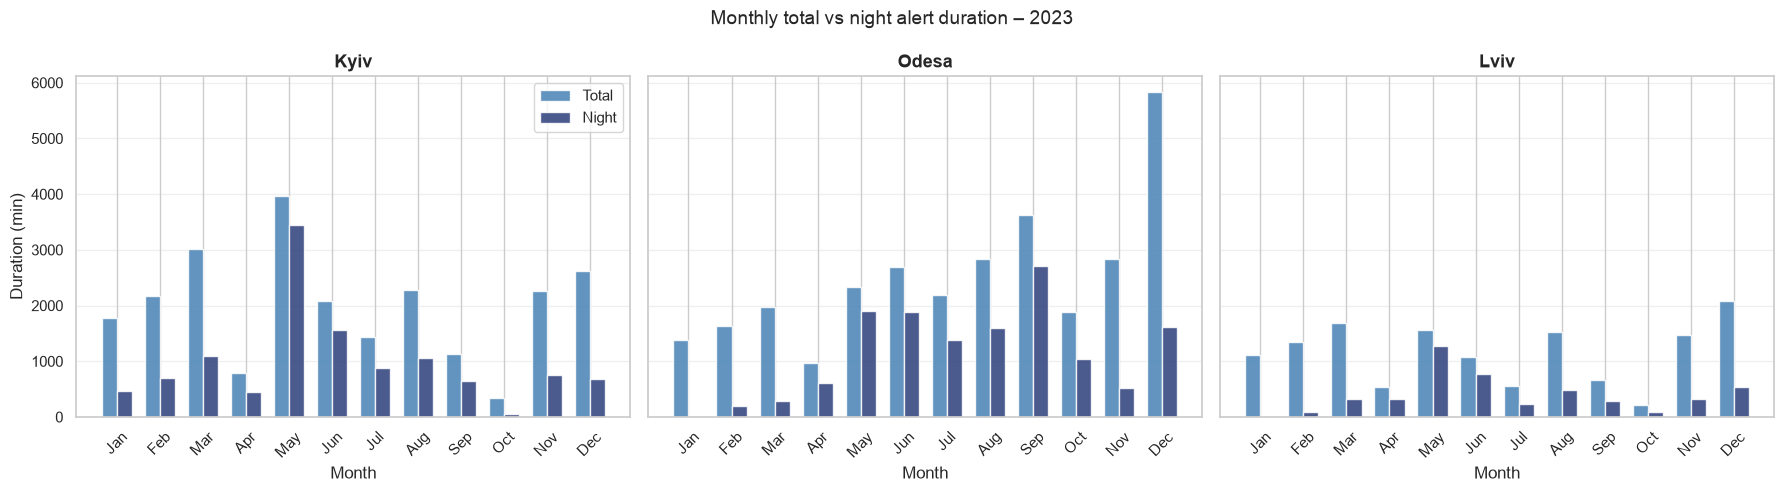

In [95]:
# %% Monthly night_min vs total_min – Kyiv, Odesa, Lviv (2023)

CITIES  = ['Kyiv', 'Odesa', 'Lviv']
MONTHS  = range(1, 13)
x       = np.arange(len(list(MONTHS)))
width   = 0.35

monthly = (
    buckets_df[
        (buckets_df['city'].isin(CITIES)) &
        (pd.to_datetime(buckets_df['date']).dt.year == 2023)
    ]
    .assign(month=pd.to_datetime(buckets_df['date']).dt.month)
    .groupby(['city', 'month'])[['night_min', 'total_min']]
    .sum()
    .reindex(pd.MultiIndex.from_product([CITIES, list(MONTHS)], names=['city', 'month']), fill_value=0)
    .reset_index()
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, city in zip(axes, CITIES):
    group = monthly[monthly['city'] == city]
    ax.bar(x - width / 2, group['total_min'], width, label='Total',  color='steelblue', alpha=0.85)
    ax.bar(x + width / 2, group['night_min'],  width, label='Night',  color='#2c3e7a',  alpha=0.85)
    ax.set_title(city, fontsize=13, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], rotation=45)
    ax.set_xlabel('Month')
    ax.grid(True, axis='y', alpha=0.3)

axes[0].set_ylabel('Duration (min)')
axes[0].legend()
fig.suptitle('Monthly total vs night alert duration – 2023', fontsize=14)
plt.tight_layout()
plt.show()

In mid-2023, all three rear cities show a simultaneous increase in both absolute night alert duration and night share, consistent with a period of intensified night-time strike activity. However, this pattern partially reverses by late 2023, suggesting a temporary campaign rather than a permanent strategic shift.

Also, as someone who lives in Kyiv, understanding it's patterns is interesting for me, so let's the plot general Kyiv duration plot with both night_min adn total_min.

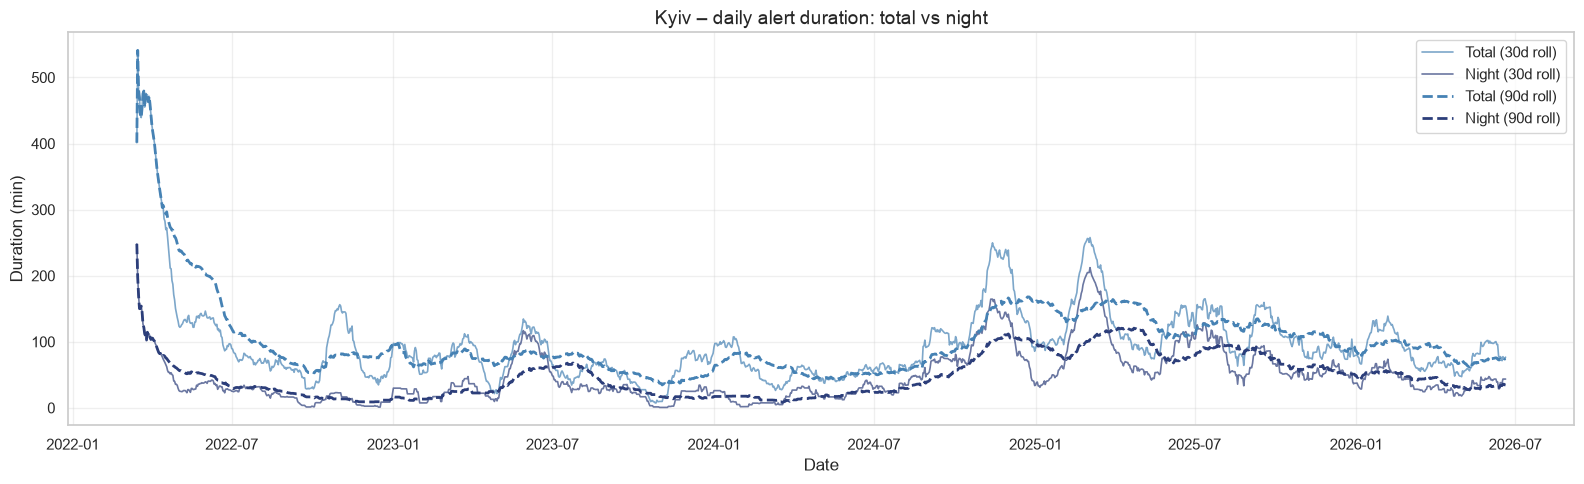

In [100]:
# %% Kyiv – total_min vs night_min with rolling smoothing

group = buckets_df[buckets_df['city'] == 'Kyiv'].sort_values('date')
dates = pd.to_datetime(group['date'])

total_roll  = group['total_min'].rolling(30,  min_periods=1).mean()
night_roll  = group['night_min'].rolling(30,  min_periods=1).mean()
total_qroll = group['total_min'].rolling(90, min_periods=1).mean()
night_qroll = group['night_min'].rolling(90, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(dates, total_roll,         alpha=0.7,  linewidth=1.2, color='steelblue', label='Total (30d roll)')
ax.plot(dates, night_roll,         alpha=0.7,  linewidth=1.2, color='#2c3e7a',   label='Night (30d roll)')
ax.plot(dates, total_qroll,                    linewidth=2.0, color='steelblue', label='Total (90d roll)', linestyle='--')
ax.plot(dates, night_qroll,                    linewidth=2.0, color='#2c3e7a',   label='Night (90d roll)', linestyle='--')

ax.set_title('Kyiv – daily alert duration: total vs night', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Duration (min)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Throughout the entire post-stabilization period (mid-2022 to 2026), Kyiv's night alert duration tracks total alert duration with a remarkably stable proportional gap, indicating that night-time targeting of the capital is not an episodic tactical choice but a persistent structural feature of how Kyiv has been struck across all phases of the war — with two notable exceptions: the opening weeks of the invasion (March–April 2022), when disproportionately high daytime activity reflected the ground-adjacent threat to the capital, and the late 2024–early 2025 spike periods, where total duration briefly surged above the stable baseline before reverting to the established night-to-total ratio.

# Ukraine Air Alert Analysis — Summary

This analysis covers 36,882 air alert events across seven Ukrainian cities from March 2022 through June 2026. Rather than counting alerts, the primary metric is total alert duration per day — a better proxy for threat intensity, since a single long strike matters more than several brief notifications. Each day's duration is further split into four time windows: night (23:00–06:00), morning (06:00–12:00), afternoon (12:00–18:00), and evening (18:00–23:00).

The seven cities were chosen to represent distinct geographic roles: Kharkiv and Sumy (northeast, near the Russian border), Zaporizhzhia and Dnipro (southeast, near the front line), Odesa (south, Black Sea coast), Lviv (western rear), and Kyiv (capital).

Two groups emerge from the data. Frontline cities show escalating alert duration with activity spread uniformly across all hours, driven by proximity to active combat. Rear cities (Kyiv, Odesa, Lviv) show lower but episodic activity with a structurally higher share of night alerts — consistent with deliberate long-range strike timing designed to maximize disruption under cover of darkness.

Kyiv's night alert duration has tracked total duration at a stable proportional gap since mid-2022, indicating night-time targeting of the capital is a persistent structural feature rather than an episodic campaign. A temporary intensification of night strikes against all three rear cities occurred in mid-2023 before partially reversing. From late 2025, alert activity surged in frontline cities while Kyiv remained at moderate levels, with Sumy and Zaporizhzhia reaching the highest daily durations in the entire dataset.

*Note: alert duration reflects when air alert systems were active, not the duration of attacks themselves. Kharkiv data contains a gap from May 2024 to February 2025 due to a data quality issue.*

Sources: https://github.com/Vadimkin/ukrainian-air-raid-sirens-dataset/blob/main/datasets/README.md